# Experiment 06: From scratch without DP

To create a run environment, you can use:

```
conda create -n from-scratch python=3.10
pip install notebook==6.2.0 matplotlib SciecenPlots matplotlib-label-lines
```

In [1]:
PRODUCTION_QUALITY = True

import json
import matplotlib.pyplot as plt
import os
import pandas as pd
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")


dpi = 300 if PRODUCTION_QUALITY else 100

plt.rcParams.update({
    'text.usetex': True,
#    'font.size': 16,
#    'font.family': 'lmodern',
    'savefig.bbox': 'tight',
    'savefig.format': 'pdf',
    'figure.constrained_layout.use': True,
    'legend.frameon': True,
    'savefig.dpi': dpi,
})

EXPERIMENT_BASE='06-few-shot-from-scratch-non-dp'

# Beamer 16:9
WIDTH=455.24408

# Marlon's paper width
#WIDTH = 469.75499

OUTPUT_DIR=f'../{EXPERIMENT_BASE}/images'

os.makedirs(OUTPUT_DIR, exist_ok=True) # make sure it exists

# image saving format
IMG_FORMAT = 'pdf'

# Mapping of full model names to abbreviations
MODEL_NAME_MAP = {
    'wrn-16-4': 'WRN-16-4',
    'koskela-net': 'KoskelaNet',
}

In [2]:
def get_figure(subplots, fraction=1.0, y_scale=False):
    fig, axes = plt.subplots(subplots[0], subplots[1], constrained_layout=True)

    return fig, axes

In [3]:
def read_json_data(file_path):
    with open(file_path, 'r') as file:
        return json.load(file)

In [4]:
def prepare_data(data):
    records = []
    for experiment_id, experiment_details in data.items():
        # Extracting values from the JSON structure
        seed = subset_size = experiment_details['configuration']['seed']
        shots = experiment_details['configuration']['shots']
        accuracy = None
        best_trial_accuracy = None

        if 'best_trial_value' in experiment_details:
            best_trial_accuracy = float(experiment_details['best_trial_value'])

        if 'best_value' in experiment_details:
            accuracy = float(experiment_details['best_value'])

        record = {
            'experiment_id': experiment_id,
            'model_name': experiment_details['configuration']['model_name'],
            'dataset_name': experiment_details['configuration']['dataset_name'],
            'shots': shots,
            'accuracy': accuracy,
            'best_trial_accuracy': best_trial_accuracy,
            'seed': seed,
        }
        records.append(record)

    return pd.DataFrame(records)

In [5]:
# Data from the paper: CIFAR-10 from scratch
paper_epsilon = [1, 2, 4, 8]
paper_accuracy = [56.8, 65.9, 73.5, 81.4]

# A function for plotting our data

In [6]:
def plot_accuracy_trends(processed_data, model_name=None, output_dir=None):
    # Sort for consistent colors across plot variations
    processed_data.sort_values(['model_name', 'shots'], inplace=True)
    
    # Filter data for the specified model if model_name is provided
    if model_name:
        processed_data = processed_data[processed_data['model_name'] == model_name]
    
    # Create a figure for plotting
    fig, ax = get_figure((1,1))
        
    # Group by model_name to plot each model's accuracy trend
    model_groups = processed_data.groupby('model_name')
    
    for model_name, group in model_groups:
        # Plot shots vs. accuracy
        ax.plot(group['shots'], group['accuracy'], label=MODEL_NAME_MAP.get(model_name, model_name), marker='o')
        
    # Set title and labels
    ax.set_title('Model accuracy by shots')
    ax.set_xlabel('Shots')
    ax.set_ylabel('Accuracy (\%)')
    
    # Plot x-axis on log scale
    ax.set_xscale('log')
    
    # Set the number of shots as x-axis ticks
    shots_values = sorted(processed_data['shots'].unique())
    ax.set_xticks(shots_values)
    
    # Rotate x-axis labels for better readability
    #ax.set_xticklabels(shots_values, rotation=45, size=15)
    
    # Set y-axis grid lines at 0.1, 0.2, 0.3, ...
    ax.set_yticks([i / 10.0 for i in range(0, 11)])
    ax.grid(axis='y', which='major', linestyle='--')

    # Add grid lines for the x-axis
    ax.grid(axis='x', which='major', linestyle='--')
    
    # Set y-axis limit
    ax.set_ylim([0, 1])
    
    # Format y-axis labels to show as percentages
    formatter = FuncFormatter(lambda y, _: '{:.0%}'.format(y))
    ax.yaxis.set_major_formatter(formatter)
    
    # Add legend
    ax.legend(loc='lower right')

    # Save the plot if an output directory is provided
    if output_dir:
        filename_suffix = model_name if model_name else 'all_models'
        filename = f'accuracy_by_shots_{filename_suffix}.pdf'
        plt.savefig(os.path.join(output_dir, filename))
    
    # Show the plot
    plt.show()

# Final plot that combines our experiment data with the (De et al., 2022) data

In [13]:
def plot_accuracy_trends(processed_data, paper_data=None, output_dir=None, model_name=None):
    # Sort for consistent colors across plot variations
    processed_data.sort_values(['model_name', 'shots'], inplace=True)
    
    # Filter data for the specified model if model_name is provided
    if model_name:
        processed_data = processed_data[processed_data['model_name'] == model_name]
    
    # Create a figure for plotting
    fig, ax = get_figure((1,1))
        
    # Group by model_name to plot each model's accuracy trend
    model_groups = processed_data.groupby('model_name')
        
    for model, group in model_groups:
        # Plot shots vs. accuracy
        ax.plot(group['shots'], group['accuracy'], label="$\epsilon$=$\infty$", marker='o', color="C4")
        
    # Set title and labels
    #ax.set_title('Model accuracy by shots')
    ax.set_xlabel("shots ($S$)", labelpad=0)
    ax.set_ylabel('Accuracy (\%)')
    
    # Plot x-axis on log scale
    ax.set_xscale('log')
    
    # Set the number of shots as x-axis ticks
    shots_values = sorted(processed_data['shots'].unique())
    ax.set_xticks(shots_values)
    
    # Rotate x-axis labels for better readability
    ax.set_xticklabels(shots_values)#, rotation=45, fontsize=15)
    
    # Set y-axis grid lines at 0.1, 0.2, 0.3, ...
    ax.set_yticks([i / 10.0 for i in range(0, 11)])
    ax.grid(axis='y', which='major', linestyle='--')

    # Adding grid lines for the x-axis
    ax.grid(axis='x', which='major', linestyle='--')
    
    # Set y-axis limit
    ax.set_ylim([0, 1])
    
    # Format y-axis labels to show as percentages
    formatter = FuncFormatter(lambda y, _: '{:.0%}'.format(y))
    ax.yaxis.set_major_formatter(formatter)
    


    # add box and ticks
    for _, spine in ax.spines.items():
        spine.set_visible(True) # You have to first turn them on
        spine.set_color('black')
        spine.set_linewidth(1)
    ax.tick_params(bottom=True, left=True, length=3)

    if paper_data:
        paper_epsilon = paper_data['epsilon']
        paper_accuracy = paper_data['accuracy']

        # Convert accuracy to fraction for plotting
        paper_accuracy_fraction = [acc / 100.0 for acc in paper_accuracy]

        # Define the x positions where the labels will be placed
        x_positions = [5, 25, 100, 500]
        
        xmin, xmax = ax.get_xlim()

        # Plot horizontal lines for paper accuracies and add labels using labelLines
        colors = ["C0", "C1", "C2", "C3"]
        for eps, acc, x_pos, c in zip(paper_epsilon, paper_accuracy_fraction, x_positions, colors):
            ax.hlines(xmin=xmin, xmax=xmax, y=acc, colors=c, linestyle='--', linewidth=2, label=f'$\epsilon$={eps}')
            ax.annotate(xy=[5, acc], text=f'$\epsilon$={eps}', backgroundcolor='white', fontsize=12, color=c)
            # Use labelLine to label this line at the position x_pos
            #labelLine(line, x=x_pos, label=f'$\epsilon={eps}$', backgroundcolor='white', fontsize=12)

    # Add legend for model lines
    order = [0, 4, 3, 2, 1]
    handles, labels = ax.get_legend_handles_labels()
    handles = [handles[o] for o in order]
    labels =  [labels[o] for o in order]
    ax.legend(handles=handles, labels=labels, loc='lower right')
    
    # Save the plot if an output directory is provided
    if output_dir:
        filename_suffix = model_name if model_name else 'all_models'
        filename = f'accuracy_by_shots_{filename_suffix}.png'
        plt.savefig(os.path.join(output_dir, filename))
    
    # Show the plot
    plt.show()


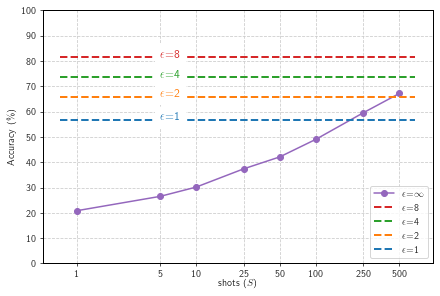

In [14]:
def plot(paper_data, model_name=None):
    file_path = f'../{EXPERIMENT_BASE}/processed-data/aggregated_data.json'
    
    # Load and prepare your data
    data = read_json_data(file_path)
    processed_data = prepare_data(data)
    
    # Plot the trends
    plot_accuracy_trends(processed_data, paper_data=paper_data, model_name=model_name, output_dir=OUTPUT_DIR)

paper_data = {
    'accuracy': paper_accuracy,
    'epsilon': paper_epsilon,
}

plot(paper_data=paper_data, model_name='wrn-16-4')